In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))
from models.baseline_model import BaselineModel
from models.improved_model import Improved_Model
from models.pretrained_model import get_resnet_model

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = "../../data/processed_data"
BATCH_SIZE = 64

In [4]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
test_set = datasets.ImageFolder(root=f"{DATA_ROOT}/test", transform=test_transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
class_names = test_set.classes

In [6]:
def evaluate_and_plot_cm(model, loader, model_name):
    model.eval()
    y_true = []
    y_pred = []
    
    print(f"Evaluating {model_name} on Test Set...")
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return accuracy_score(y_true, y_pred)

In [7]:
def compare_models(results_dict):
    names = list(results_dict.keys())
    # Convert probabilities (0.95) to percentages (95.0)
    values = [v * 100 if v <= 1.0 else v for v in results_dict.values()]
    
    plt.figure(figsize=(10, 6))
    # Using a professional color palette
    bars = plt.bar(names, values, color=['#808080', '#1f77b4', '#2ca02c'])
    
    plt.ylim(0, 105) # Increased to 105 to give space for text labels
    plt.ylabel('Test Accuracy (%)')
    plt.title('Final Model Performance Comparison')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        # Formatting to 2 decimal places with a % sign
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, 
                 f'{yval:.2f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [8]:
model1 = torch.load("model1_baseline.pt", map_location=DEVICE, weights_only=False).to(DEVICE)
model2 = torch.load("model2_improved.pt", map_location=DEVICE, weights_only=False).to(DEVICE)
model3 = torch.load("model3_pretrained.pt", map_location=DEVICE, weights_only=False).to(DEVICE)

model1.eval()
model2.eval()
model3.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Evaluating Model 1 (Baseline) on Test Set...

--- Model 1 (Baseline) Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.45      0.60       450
              Forest       0.00      0.00      0.00       450
HerbaceousVegetation       0.38      0.04      0.07       450
             Highway       0.53      0.52      0.52       375
          Industrial       0.40      1.00      0.57       375
             Pasture       0.27      0.82      0.41       300
       PermanentCrop       0.46      0.11      0.18       375
         Residential       0.59      0.67      0.63       450
               River       0.48      0.71      0.57       375
             SeaLake       0.94      0.83      0.88       450

            accuracy                           0.50      4050
           macro avg       0.50      0.51      0.44      4050
        weighted avg       0.51      0.50      0.44      4050



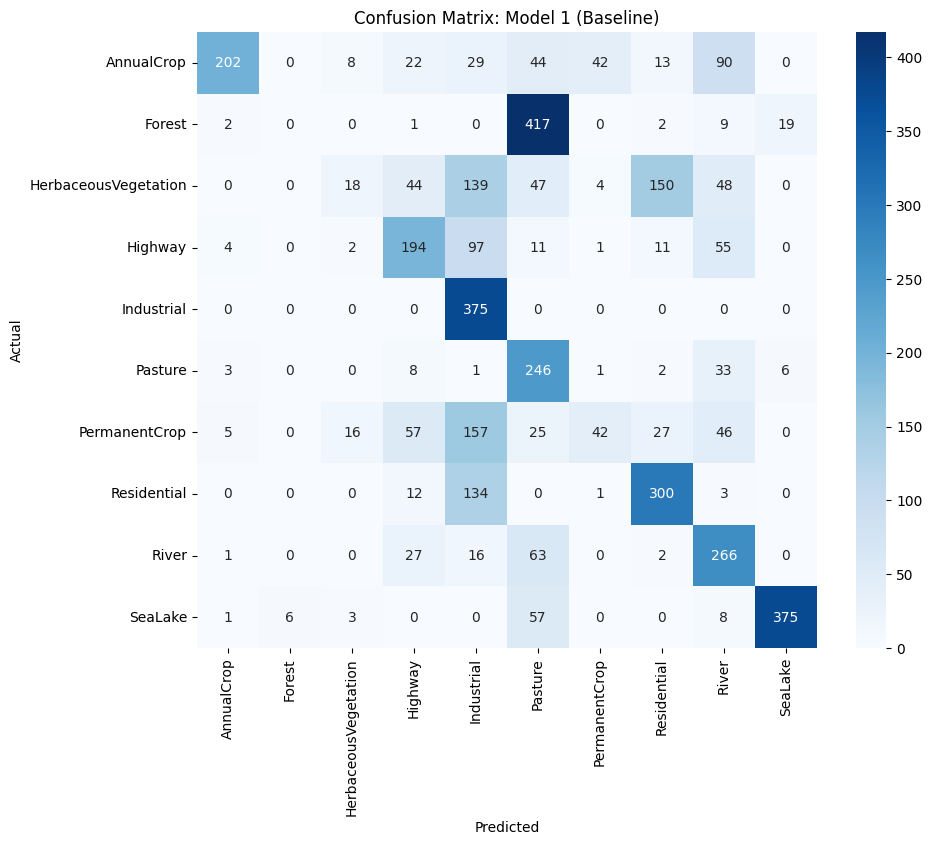

Evaluating Model 2 (Improved) on Test Set...

--- Model 2 (Improved) Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.94      0.94       450
              Forest       0.98      0.98      0.98       450
HerbaceousVegetation       0.95      0.92      0.94       450
             Highway       0.92      0.97      0.95       375
          Industrial       0.96      0.99      0.97       375
             Pasture       0.92      0.97      0.94       300
       PermanentCrop       0.92      0.91      0.92       375
         Residential       0.99      0.99      0.99       450
               River       0.97      0.92      0.95       375
             SeaLake       1.00      0.97      0.98       450

            accuracy                           0.96      4050
           macro avg       0.96      0.96      0.96      4050
        weighted avg       0.96      0.96      0.96      4050



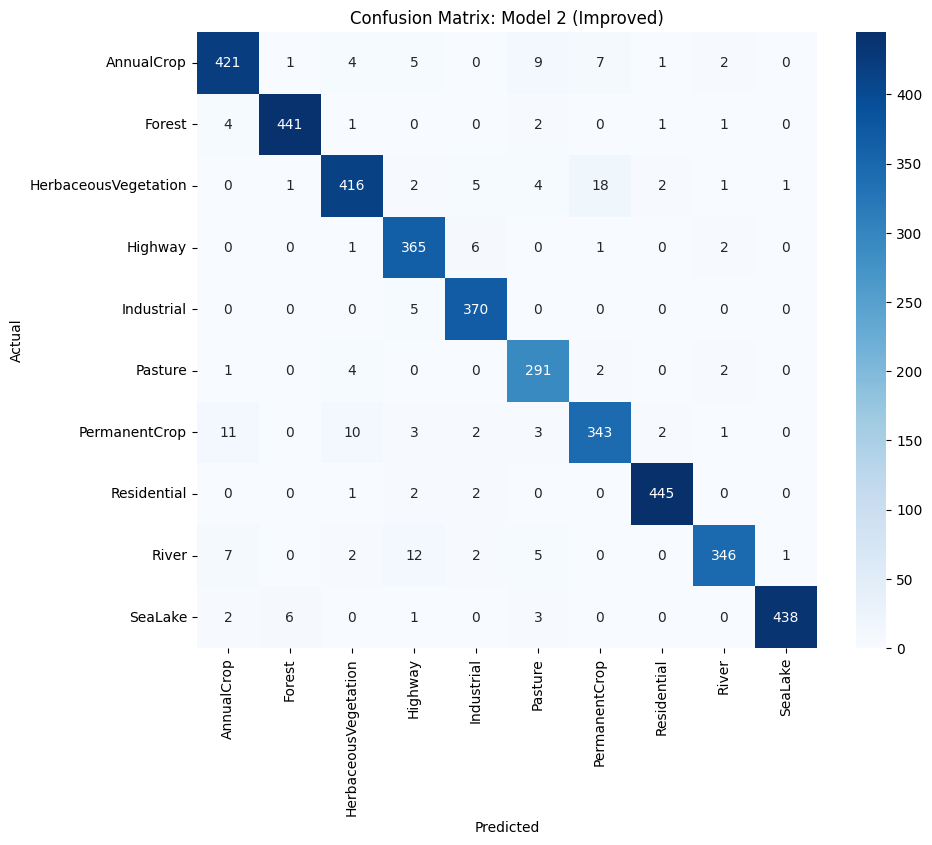

Evaluating Model 3 (ResNet-50) on Test Set...

--- Model 3 (ResNet-50) Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.98      0.97       450
              Forest       1.00      1.00      1.00       450
HerbaceousVegetation       0.96      0.98      0.97       450
             Highway       0.98      0.98      0.98       375
          Industrial       1.00      0.98      0.99       375
             Pasture       0.95      0.97      0.96       300
       PermanentCrop       0.99      0.92      0.95       375
         Residential       0.98      0.99      0.99       450
               River       0.98      0.98      0.98       375
             SeaLake       0.99      1.00      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



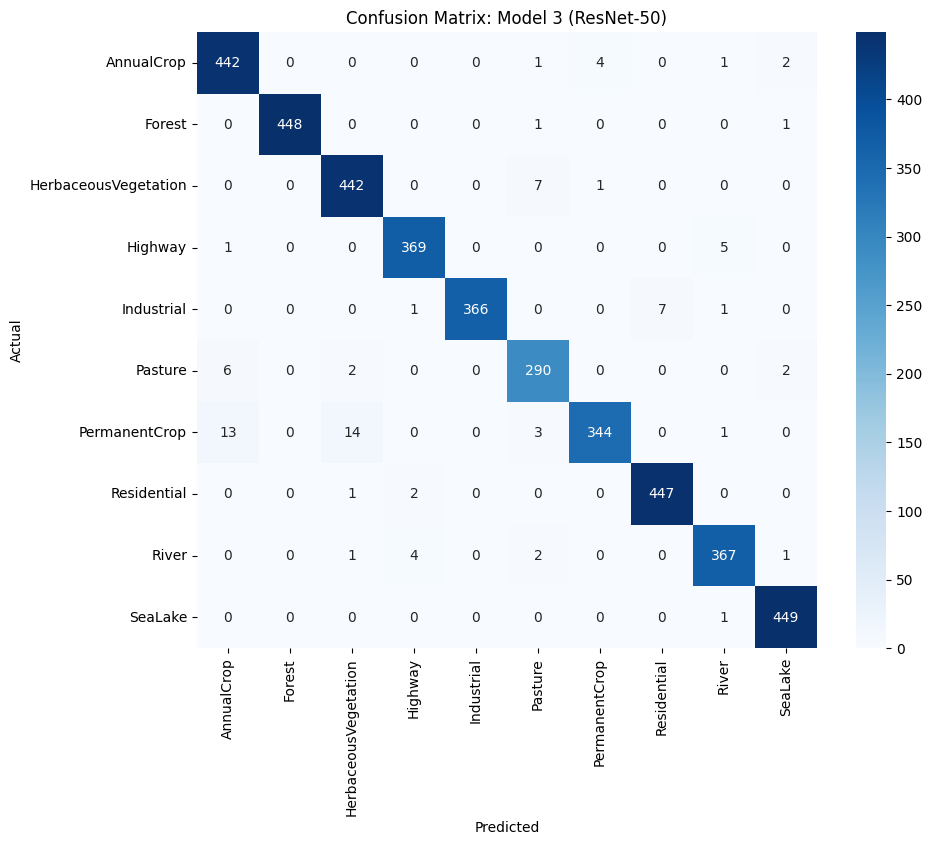

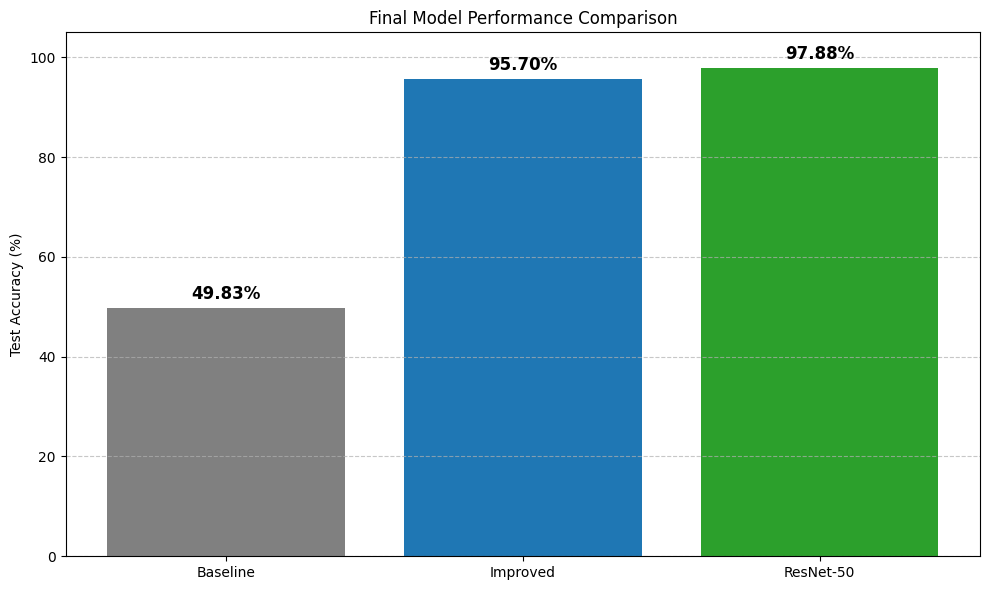

In [9]:
# Example of how to run the final comparison:
acc1 = evaluate_and_plot_cm(model1, test_loader, "Model 1 (Baseline)")
acc2 = evaluate_and_plot_cm(model2, test_loader, "Model 2 (Improved)")
acc3 = evaluate_and_plot_cm(model3, test_loader, "Model 3 (ResNet-50)")

final_results = {"Baseline": acc1, "Improved": acc2, "ResNet-50": acc3}
compare_models(final_results)